## Preparando el entorno 

In [3]:
#%pip install pandas matplotlib seaborn requests plotly numpy scikit-learn

## Extrayendo los datos de una api 

In [4]:
#%pip install pandas requests

import pandas as pd
import requests

# URL del JSON crudo desde GitHub (versión RAW)
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

# Obtener datos con requests
response = requests.get(url)
data = response.json()  # Convertimos la respuesta en JSON

# Convertir a DataFrame
df = pd.DataFrame(data)

# Mostrar las primeras filas
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## Conociendo el DataFrame 

In [5]:
print("Dimensiones del dataset:", df.shape)
print("\nColumnas:\n", df.columns)
print("\nTipos de datos:\n", df.dtypes)
print("\nValores únicos en Churn:\n", df['Churn'].value_counts())


Dimensiones del dataset: (7267, 6)

Columnas:
 Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

Tipos de datos:
 customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object

Valores únicos en Churn:
 Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


## Comprobando incoherencias o detalles en los datos

In [6]:
# Expandir columnas de diccionarios
df_customer = df['customer'].apply(pd.Series)
df_phone = df['phone'].apply(pd.Series)
df_internet = df['internet'].apply(pd.Series)
df_account = df['account'].apply(pd.Series)

# Unir todo en un solo DataFrame limpio
df_clean = pd.concat([df.drop(columns=['customer', 'phone', 'internet', 'account']),
                      df_customer, df_phone, df_internet, df_account], axis=1)

# Verificar el nuevo DataFrame
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7267 non-null   object
 1   Churn             7267 non-null   object
 2   gender            7267 non-null   object
 3   SeniorCitizen     7267 non-null   int64 
 4   Partner           7267 non-null   object
 5   Dependents        7267 non-null   object
 6   tenure            7267 non-null   int64 
 7   PhoneService      7267 non-null   object
 8   MultipleLines     7267 non-null   object
 9   InternetService   7267 non-null   object
 10  OnlineSecurity    7267 non-null   object
 11  OnlineBackup      7267 non-null   object
 12  DeviceProtection  7267 non-null   object
 13  TechSupport       7267 non-null   object
 14  StreamingTV       7267 non-null   object
 15  StreamingMovies   7267 non-null   object
 16  Contract          7267 non-null   object
 17  PaperlessBilli

## Validaciones y limpieza de datos

In [7]:
## Identificar columnas que tienen diccionarios : 
for col in df_clean.columns:
    if df_clean[col].apply(lambda x: isinstance(x, dict)).any():
        print(f"⚠️ La columna '{col}' contiene diccionarios.")

##Expandir Charges a columnas separadas 
charges_expanded = pd.json_normalize(df_clean['Charges'])
df_clean = pd.concat([df_clean.drop(columns=['Charges']), charges_expanded], axis=1)



⚠️ La columna 'Charges' contiene diccionarios.


In [8]:
# Valores faltantes
print("Valores nulos por columna:\n", df_clean.isnull().sum())

# Duplicados (ya que no hay columnas con diccionarios, ahora sí se puede hacer sin error)
print("\nDuplicados:", df_clean.duplicated().sum())

# Tipos de datos
print("\nTipos de datos:\n", df_clean.dtypes)

# Valores únicos por columna (para buscar inconsistencias como ' Yes', 'No ', etc.)
for col in df_clean.columns:
    print(f"\nColumna: {col}")
    print(df_clean[col].unique())


Valores nulos por columna:
 customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly             0
Total               0
dtype: int64

Duplicados: 0

Tipos de datos:
 customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract        

In [9]:
import pandas as pd
import numpy as np

# Convertir columna 'Total' a numérica, forzando errores a NaN
df_clean['Total'] = pd.to_numeric(df_clean['Total'], errors='coerce')

# Revisar cuántos valores NaN quedaron en 'Total' después de la conversión
print("Valores NaN en 'Total':", df_clean['Total'].isnull().sum())

# Limpiar columna 'Churn': reemplazar valores vacíos por NaN
df_clean['Churn'] = df_clean['Churn'].replace('', np.nan)

# Revisar cuántos valores NaN hay en 'Churn'
print("Valores NaN en 'Churn':", df_clean['Churn'].isnull().sum())

# Opción: eliminar filas donde 'Churn' sea NaN
df_clean = df_clean.dropna(subset=['Churn'])

# Confirmar limpieza
print("Datos después de limpieza de 'Churn':")
print(df_clean['Churn'].value_counts(dropna=False))
print("Dimensiones después de limpieza:", df_clean.shape)


Valores NaN en 'Total': 11
Valores NaN en 'Churn': 224
Datos después de limpieza de 'Churn':
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Dimensiones después de limpieza: (7043, 21)


## Manejando la data , Columna de cuentas diarias 

In [10]:
# Crear columna 'Cuentas_Diarias' asumiendo 30 días por mes
df_clean['Cuentas_Diarias'] = df_clean['Monthly'] / 30

# Mostrar algunas filas para verificar
print(df_clean[['Monthly', 'Cuentas_Diarias']].head())


   Monthly  Cuentas_Diarias
0     65.6         2.186667
1     59.9         1.996667
2     73.9         2.463333
3     98.0         3.266667
4     83.9         2.796667


## Analisis Descriptivos de los datos

In [11]:
# Seleccionamos solo las columnas numéricas
numericas = df_clean.select_dtypes(include=['number'])

# Estadísticas descriptivas para numéricas
estadisticas = numericas.describe().T

# Calcular la mediana solo para numéricas
medianas = numericas.median()

# Añadimos la mediana
estadisticas['median'] = medianas

print(estadisticas)


                  count         mean          std        min         25%  \
SeniorCitizen    7043.0     0.162147     0.368612   0.000000    0.000000   
tenure           7043.0    32.371149    24.559481   0.000000    9.000000   
Monthly          7043.0    64.761692    30.090047  18.250000   35.500000   
Total            7032.0  2283.300441  2266.771362  18.800000  401.450000   
Cuentas_Diarias  7043.0     2.158723     1.003002   0.608333    1.183333   

                      50%        75%          max    median  
SeniorCitizen       0.000     0.0000     1.000000     0.000  
tenure             29.000    55.0000    72.000000    29.000  
Monthly            70.350    89.8500   118.750000    70.350  
Total            1397.475  3794.7375  8684.800000  1397.475  
Cuentas_Diarias     2.345     2.9950     3.958333     2.345  


## Distribución de evasión

C:\Users\IchBi\AppData\Local\Temp\ipykernel_6276\1083523502.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='Set2')


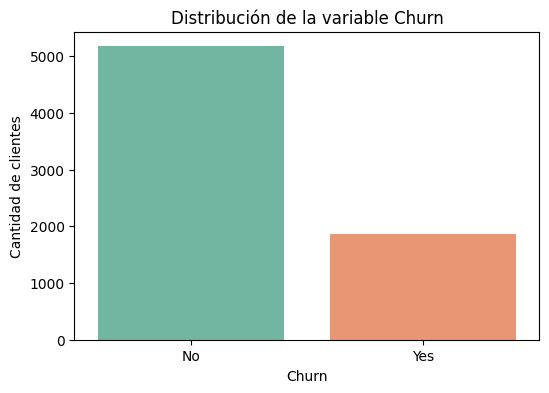

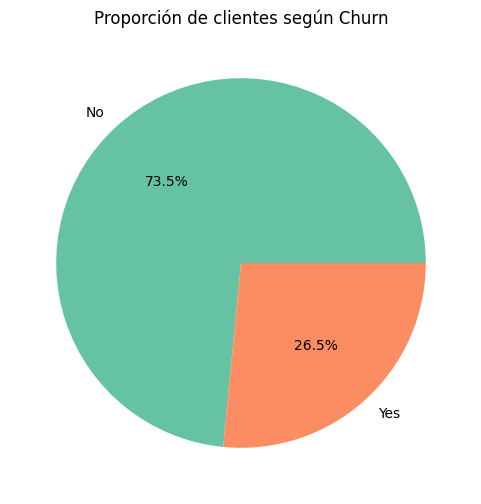

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Conteo de cada categoría en la columna 'Churn'
churn_counts = df_clean['Churn'].value_counts()

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='Set2')
plt.title('Distribución de la variable Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.show()

# Gráfico de pastel
plt.figure(figsize=(6,6))
plt.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Proporción de clientes según Churn')
plt.show()


## Explorando los datos segun variables categoricas 

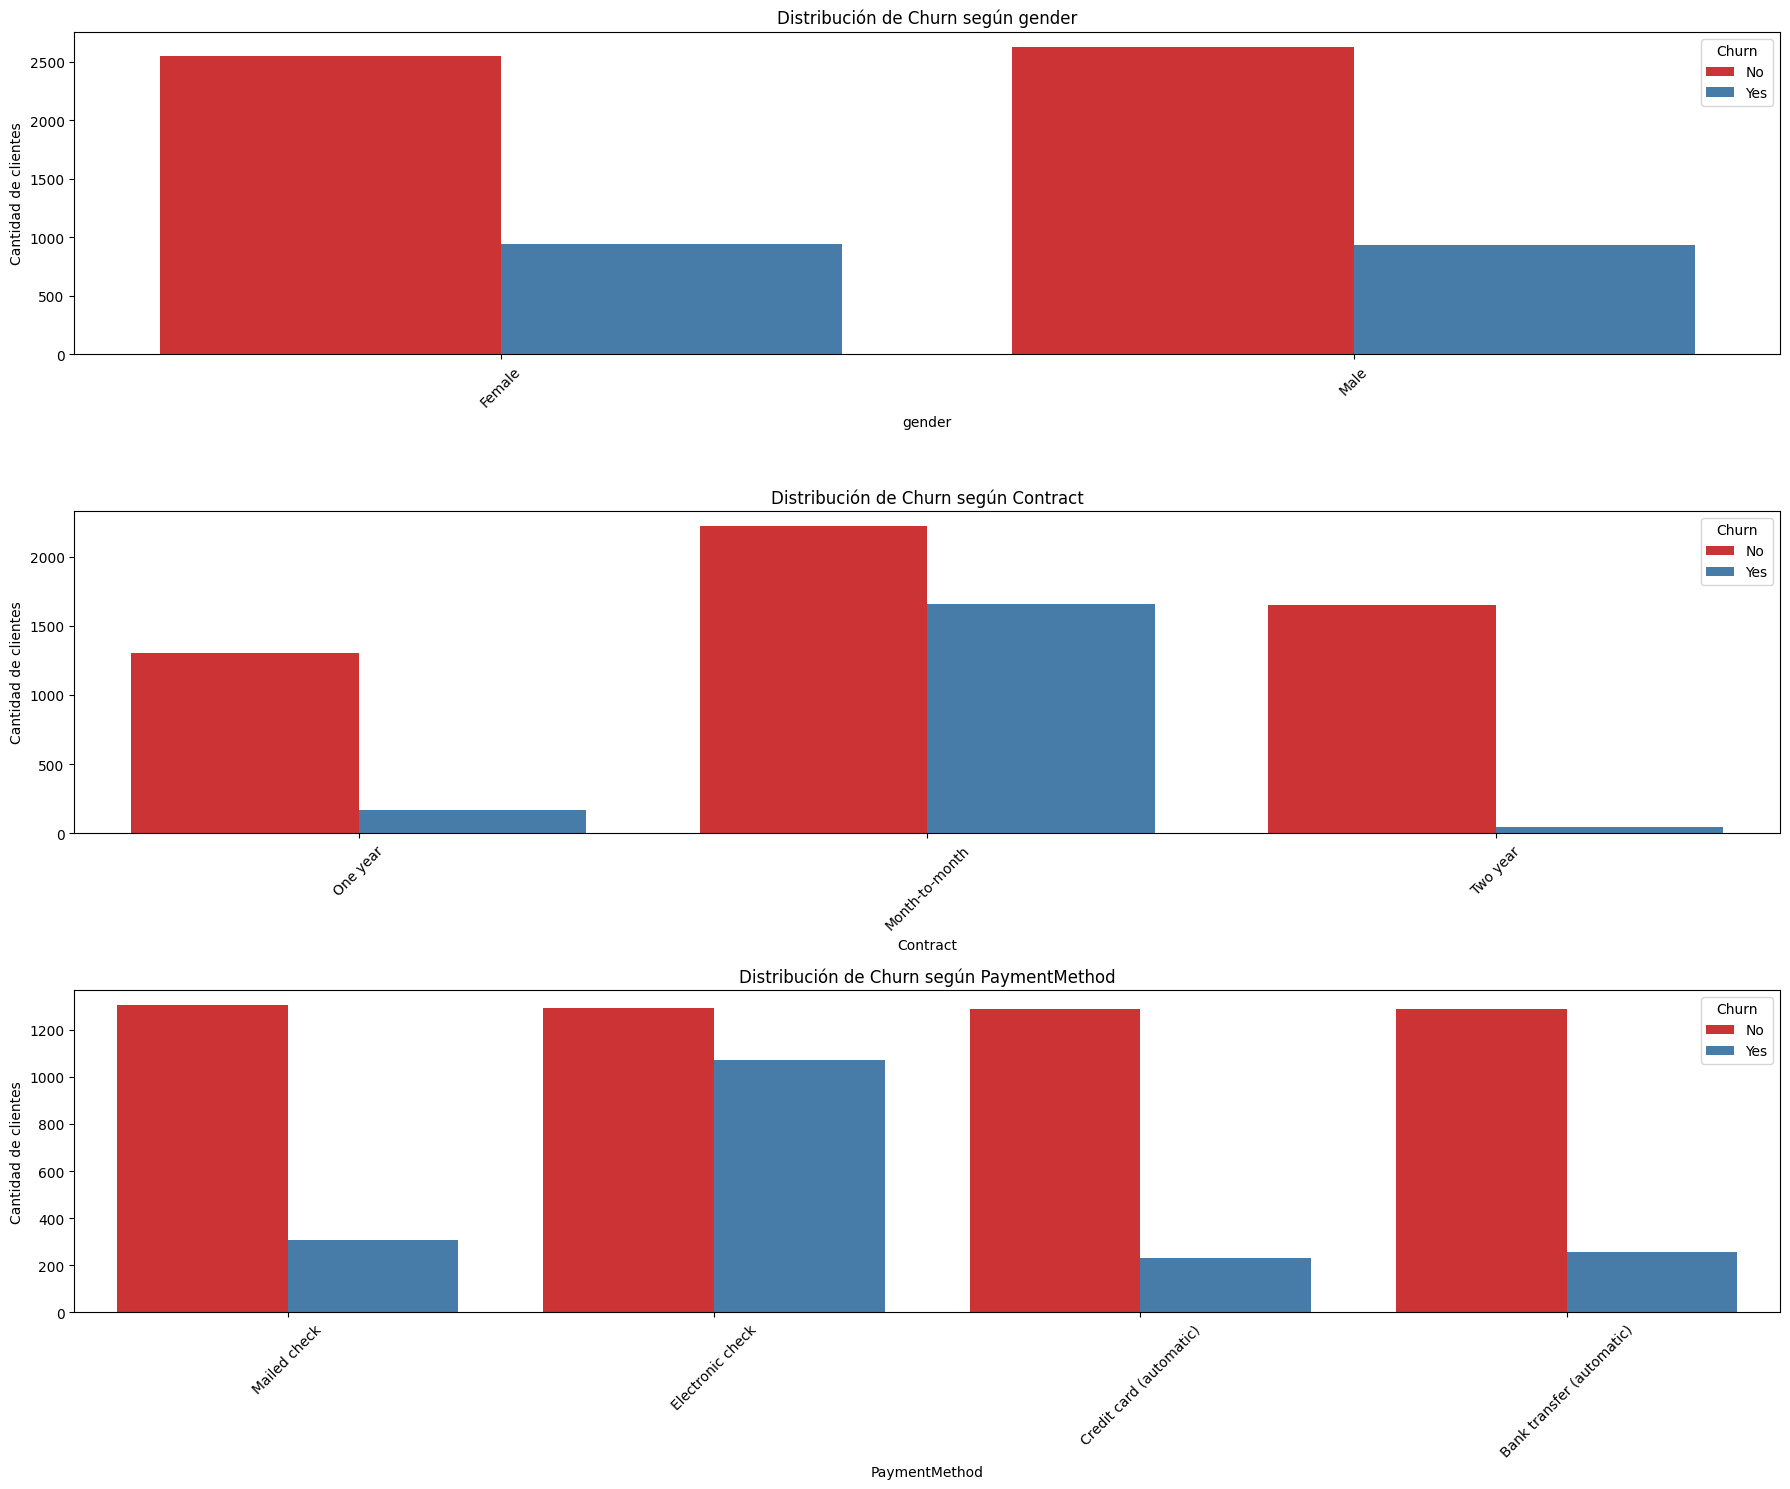

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variables categóricas a analizar con churn
categorical_vars = ['gender', 'Contract', 'PaymentMethod']

# Configurar tamaño de figura para múltiples gráficos
plt.figure(figsize=(18, 5 * len(categorical_vars)))

for i, var in enumerate(categorical_vars, 1):
    plt.subplot(len(categorical_vars), 1, i)
    sns.countplot(data=df_clean, x=var, hue='Churn', palette='Set1')
    plt.title(f'Distribución de Churn según {var}')
    plt.xlabel(var)
    plt.ylabel('Cantidad de clientes')
    plt.legend(title='Churn')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Distribución de variables numéricas entre clientes que cancelaron y los que no

C:\Users\IchBi\AppData\Local\Temp\ipykernel_6276\1740648792.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y=var, palette='Set2')
C:\Users\IchBi\AppData\Local\Temp\ipykernel_6276\1740648792.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y=var, palette='Set2')


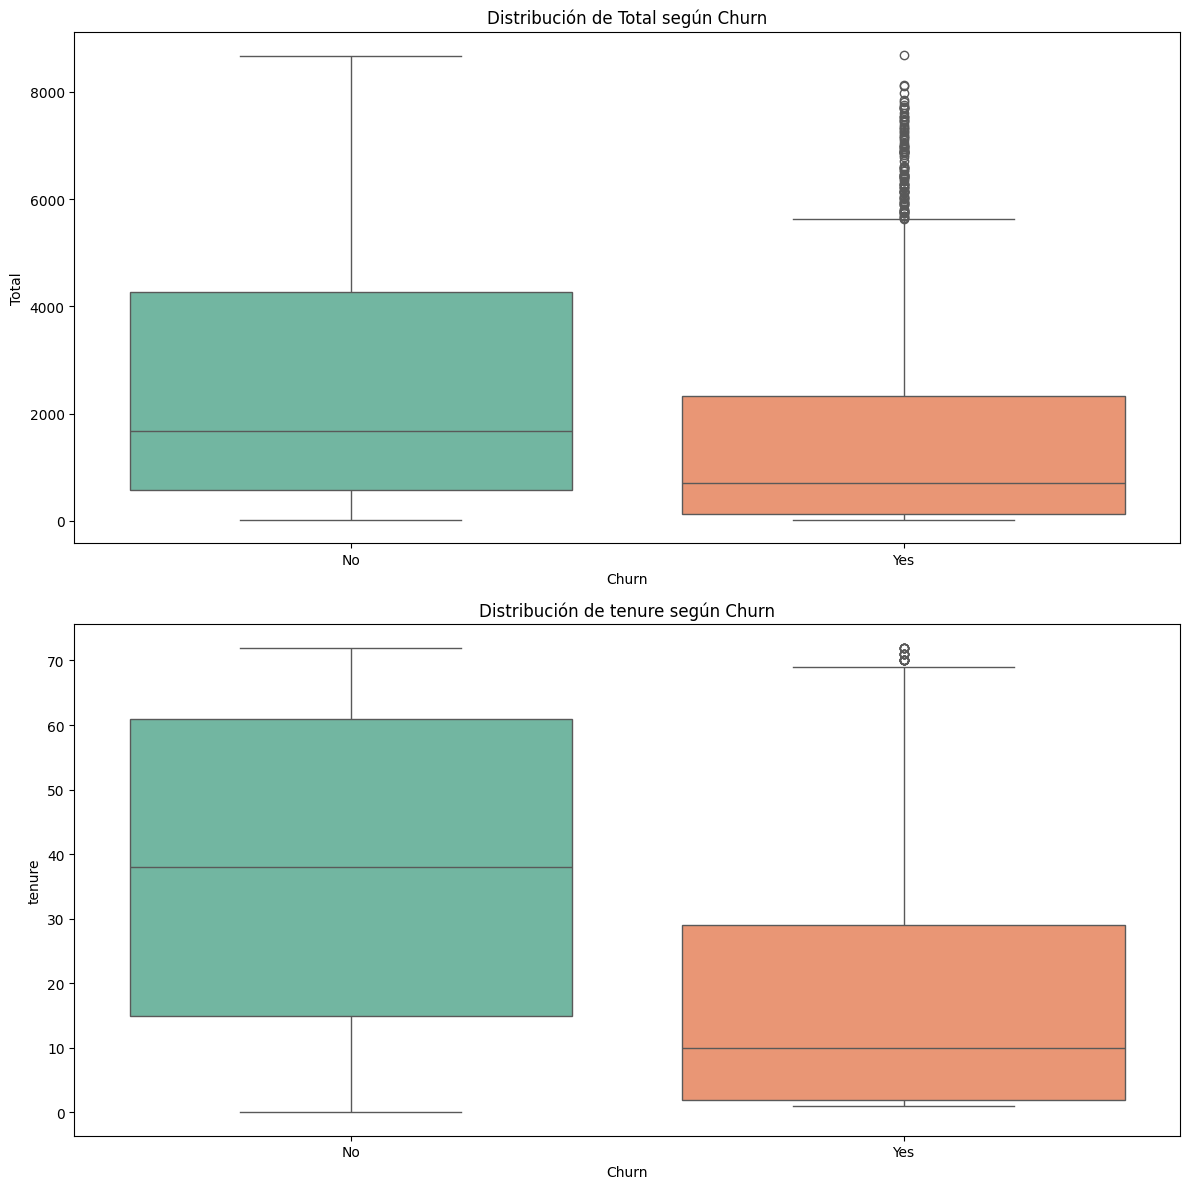

✅ Archivo CSV generado con éxito.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir la columna 'Total' a numérica si no lo está
df_clean['Total'] = pd.to_numeric(df_clean['Total'], errors='coerce')

numeric_vars = ['Total', 'tenure']

plt.figure(figsize=(12, 6 * len(numeric_vars)))

for i, var in enumerate(numeric_vars, 1):
    plt.subplot(len(numeric_vars), 1, i)
    sns.boxplot(data=df_clean, x='Churn', y=var, palette='Set2')
    plt.title(f'Distribución de {var} según Churn')
    plt.xlabel('Churn')
    plt.ylabel(var)

plt.tight_layout()
plt.show()

# Exportar a CSV
df_clean.to_csv("TelecomX_clean_data.csv", index=False)
print("✅ Archivo CSV generado con éxito.")

